# Análisis exploratorio de datos (EDA) — FinanciAr

Issue #135. Primera parte: mirar los datos como son (precios, retornos,
los indicadores que ya usamos). Segunda parte, más de fondo: buscar cosas
que hoy **no** usamos y podrían sumar — no solo confirmar o descartar lo
que ya está.

Usamos los 22 tickers que hoy trae `data-colector` (los mismos con los que
entrenamos) y 3 años de historial (750 ruedas) por ticker.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.stattools import acf

from src.data import attach_macro_feature, fetch_available_tickers, fetch_history, fetch_macro_series
from src.indicators import macd_histogram, rsi_series, sma
from src.lstm import FEATURE_NAMES, build_features

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

## 1. Qué datos tenemos

In [2]:
tickers = fetch_available_tickers()
print(f"{len(tickers)} tickers: {tickers}")

macro = fetch_macro_series()
print(f"Serie macro: {len(macro)} puntos" if macro is not None else "Serie macro: no se pudo traer")

22 tickers: ['GOLD', 'OIL', 'ECOG', 'VALO', 'COME', 'TRAN', 'TGNO4', 'ALUA', 'LOMA', 'TGSU2', 'YPFD', 'BBAR', 'BYMA', 'PAMP', 'METR', 'GGAL', 'SUPV', 'CEPU', 'CRES', 'EDN', 'TXAR', 'BMA']


Serie macro: 750 puntos


In [3]:
histories: dict[str, pd.DataFrame] = {}
failed: list[str] = []
for t in tickers:
    try:
        df = fetch_history(t)
        if macro is not None:
            df = attach_macro_feature(df, "macro_rate", macro)
        histories[t] = df
    except Exception as exc:  # noqa: BLE001 - EDA exploratorio, solo queremos loguear y seguir
        failed.append(t)
        print(f"  no se pudo traer {t}: {exc}")

print(f"\nTrajimos {len(histories)} de {len(tickers)}. Fallaron: {failed or 'ninguno'}")


Trajimos 22 de 22. Fallaron: ninguno


In [4]:
coverage = pd.DataFrame(
    {
        "dias": {t: len(df) for t, df in histories.items()},
        "desde": {t: df.index.min().date() for t, df in histories.items()},
        "hasta": {t: df.index.max().date() for t, df in histories.items()},
    }
).sort_values("dias")
coverage

,dias,desde,hasta
ECOG,369,2025-01-27,2026-08-03
YPFD,735,2023-08-03,2026-07-31
EDN,735,2023-08-03,2026-07-31
CRES,735,2023-08-03,2026-07-31
CEPU,735,2023-08-03,2026-07-31
SUPV,735,2023-08-03,2026-07-31
GGAL,735,2023-08-03,2026-07-31
METR,735,2023-08-03,2026-07-31
PAMP,735,2023-08-03,2026-07-31
BYMA,735,2023-08-03,2026-07-31


Casi todos tienen entre 735 y 750 días (esperable, pedimos 3 años). El que
menos tiene se ve raro a simple vista — lo retomamos en la sección 3.

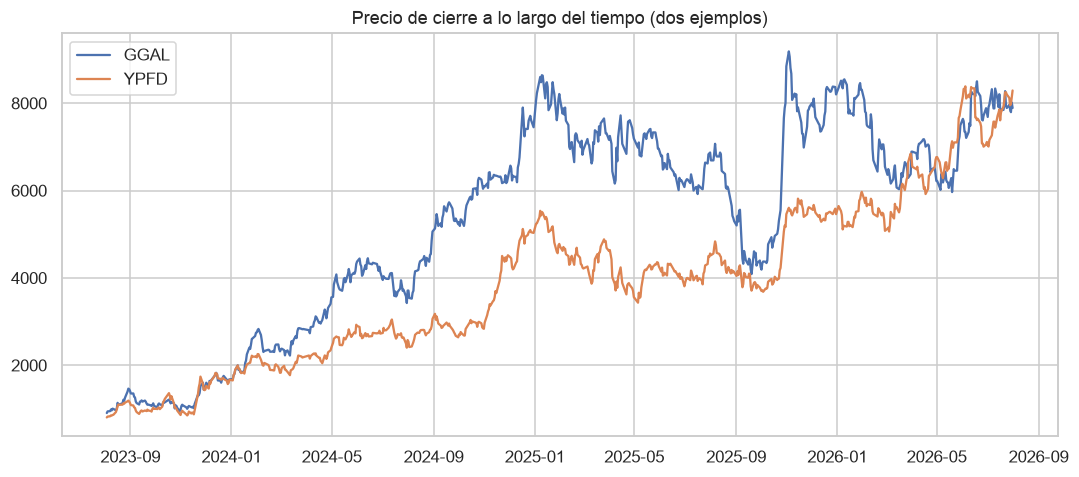

In [5]:
example_tickers = ["GGAL", "YPFD"] if "GGAL" in histories and "YPFD" in histories else list(histories)[:2]
fig, ax = plt.subplots(figsize=(10, 4.5))
for t in example_tickers:
    ax.plot(histories[t].index, histories[t]["close"], label=t)
ax.set_title("Precio de cierre a lo largo del tiempo (dos ejemplos)")
ax.legend()
plt.tight_layout()
plt.show()

Cada acción tiene su propia escala de precio, por eso para comparar entre
acciones y entrenar un solo modelo no se usa el precio en sí, sino cuánto
**cambia** de un día al otro (el retorno).

## 2. Cuánto sube o baja un día común

El "retorno logarítmico" es básicamente el % de cambio del precio de un
día al siguiente. Un valor de 0.02 es "subió 2%", uno de -0.02 es "bajó
2%".

In [6]:
returns_by_ticker = {}
for t, df in histories.items():
    r = np.diff(np.log(df["close"].to_numpy(dtype=np.float64)))
    returns_by_ticker[t] = r

all_returns = np.concatenate(list(returns_by_ticker.values()))
mean, std = all_returns.mean(), all_returns.std()
print(f"en un día común, el retorno promedio es {mean:.2%} y se mueve típicamente +/- {std:.2%}")
print(f"el día más flojo fue {all_returns.min():.1%} y el mejor {all_returns.max():.1%}")

outlier_mask = np.abs(all_returns - mean) > 4 * std
print(f"\ndías raros (más de 4 desvíos de la media): {outlier_mask.sum()} de {len(all_returns)}"
      f" ({100*outlier_mask.mean():.2f}%)")

en un día común, el retorno promedio es 0.21% y se mueve típicamente +/- 4.12%
el día más flojo fue -231.4% y el mejor 33.6%

días raros (más de 4 desvíos de la media): 59 de 15812 (0.37%)


/var/folders/1d/9jg8xmnn219f98tt4495rmhm0000gn/T/ipykernel_76579/2717929185.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(box_data, tick_labels=box_labels, vert=True)


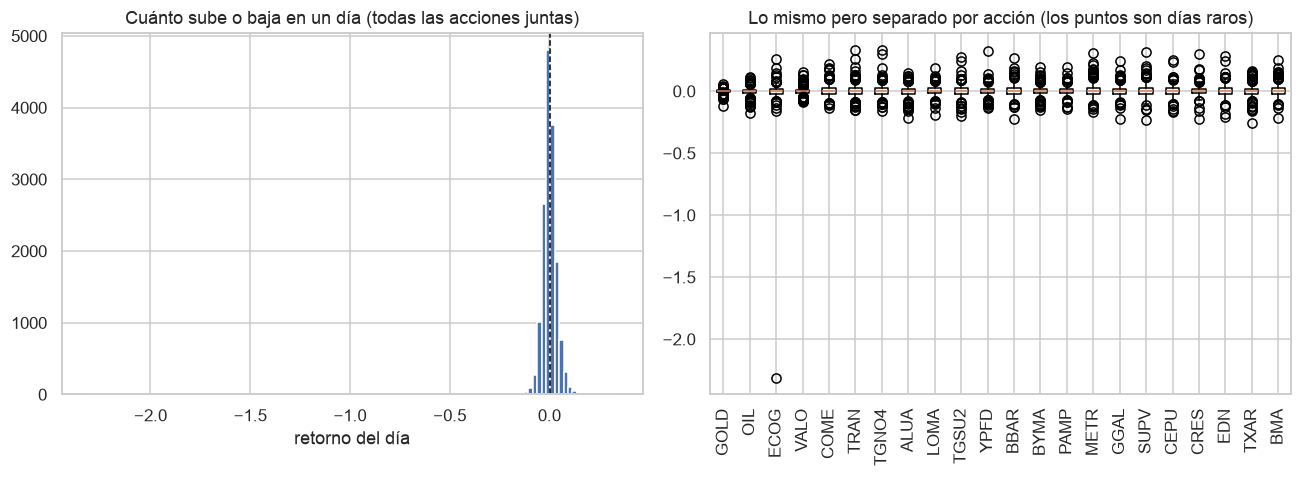

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(all_returns, bins=120, color=sns.color_palette()[0])
axes[0].axvline(mean, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Cuánto sube o baja en un día (todas las acciones juntas)")
axes[0].set_xlabel("retorno del día")

box_data = [returns_by_ticker[t] for t in tickers if t in returns_by_ticker]
box_labels = [t for t in tickers if t in returns_by_ticker]
axes[1].boxplot(box_data, tick_labels=box_labels, vert=True)
axes[1].set_xticklabels(box_labels, rotation=90)
axes[1].set_title("Lo mismo pero separado por acción (los puntos son días raros)")
plt.tight_layout()
plt.show()

La mayoría de los días el movimiento es chico, pero de vez en cuando pasa
algo grande — mucho más seguido de lo que pasaría si fuera todo al azar.
Veamos cuáles fueron esos días raros.

In [8]:
worst = []
for t, r in returns_by_ticker.items():
    idx = np.argmax(np.abs(r - r.mean()))
    worst.append((t, histories[t].index[idx + 1].date(), r[idx]))
worst_df = pd.DataFrame(worst, columns=["ticker", "fecha", "retorno"]).sort_values(
    "retorno", key=abs, ascending=False
).head(15)
worst_df

,ticker,fecha,retorno
2,ECOG,2025-08-19,-2.313635
5,TRAN,2023-11-21,0.335910
6,TGNO4,2023-11-21,0.331868
10,YPFD,2023-11-21,0.326531
16,SUPV,2025-10-27,0.314299
14,METR,2025-10-27,0.308037
18,CRES,2023-11-21,0.299863
19,EDN,2023-11-21,0.282116
9,TGSU2,2023-11-21,0.271922
11,BBAR,2025-10-27,0.269767


## 3. Dos cosas para marcar de los días raros

- **ECOG cayó casi 90% en un solo día** (19/08/2025) y encima es el ticker
  con menos historia de todos (369 días contra ~735 del resto, ver la
  tabla de la sección 1). Es un salto tan grande que huele a error de
  dato más que a movimiento real de mercado. Por las dudas, **lo sacamos
  del resto de este análisis** (secciones 8 en adelante) para que no
  distorsione nada — y lo dejamos marcado como pendiente de revisar antes
  de seguir entrenando con él.
- **El resto de los días raros no son casualidad, son elecciones**: de los
  otros 14 días de la lista, 6 son el 21/11/2023 (balotaje presidencial) y
  7 son el 27/10/2025 (elecciones legislativas). Buena señal: el dato
  refleja el mercado real.

## 4. ¿Hay algún día o mes que se comporte distinto?

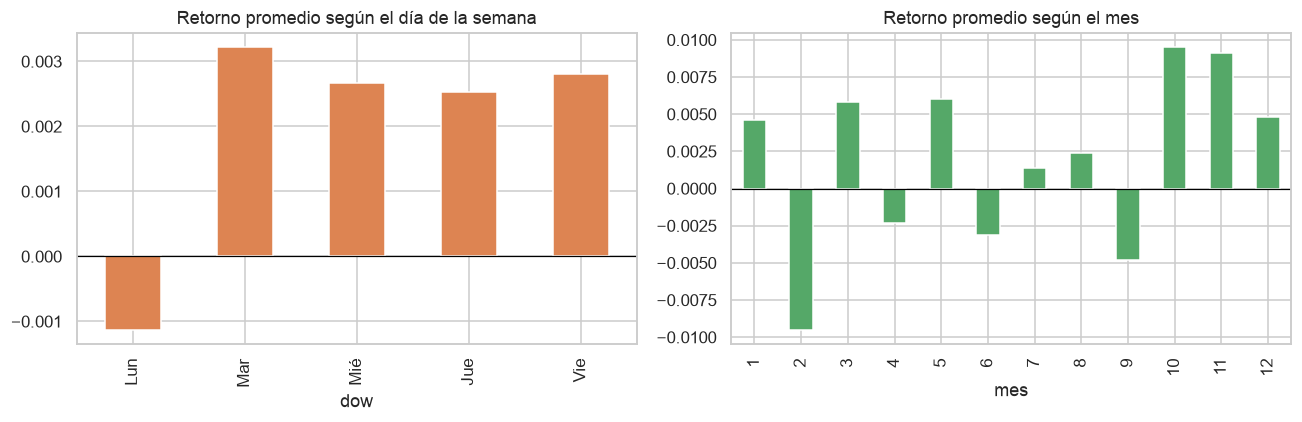

In [9]:
rows = []
for t, df in histories.items():
    r = pd.Series(returns_by_ticker[t], index=df.index[1:])
    rows.append(pd.DataFrame({"ticker": t, "retorno": r, "dow": r.index.dayofweek, "mes": r.index.month}))
panel = pd.concat(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
panel.groupby("dow")["retorno"].mean().reindex(range(5)).rename(
    index=dict(enumerate(["Lun", "Mar", "Mié", "Jue", "Vie"]))
).plot.bar(ax=axes[0], color=sns.color_palette()[1])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Retorno promedio según el día de la semana")

panel.groupby("mes")["retorno"].mean().plot.bar(ax=axes[1], color=sns.color_palette()[2])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Retorno promedio según el mes")
plt.tight_layout()
plt.show()

No salta nada tan fuerte como para justificar agregarlo como feature —
parece más ruido que un patrón real.

## 5. Los indicadores que ya usamos

Los modelos no miran el precio pelado, miran 8 números calculados a partir
de él (`src/lstm.py::FEATURE_NAMES`). Antes de analizarlos en frío, veamos
cómo se ven en un ejemplo real.

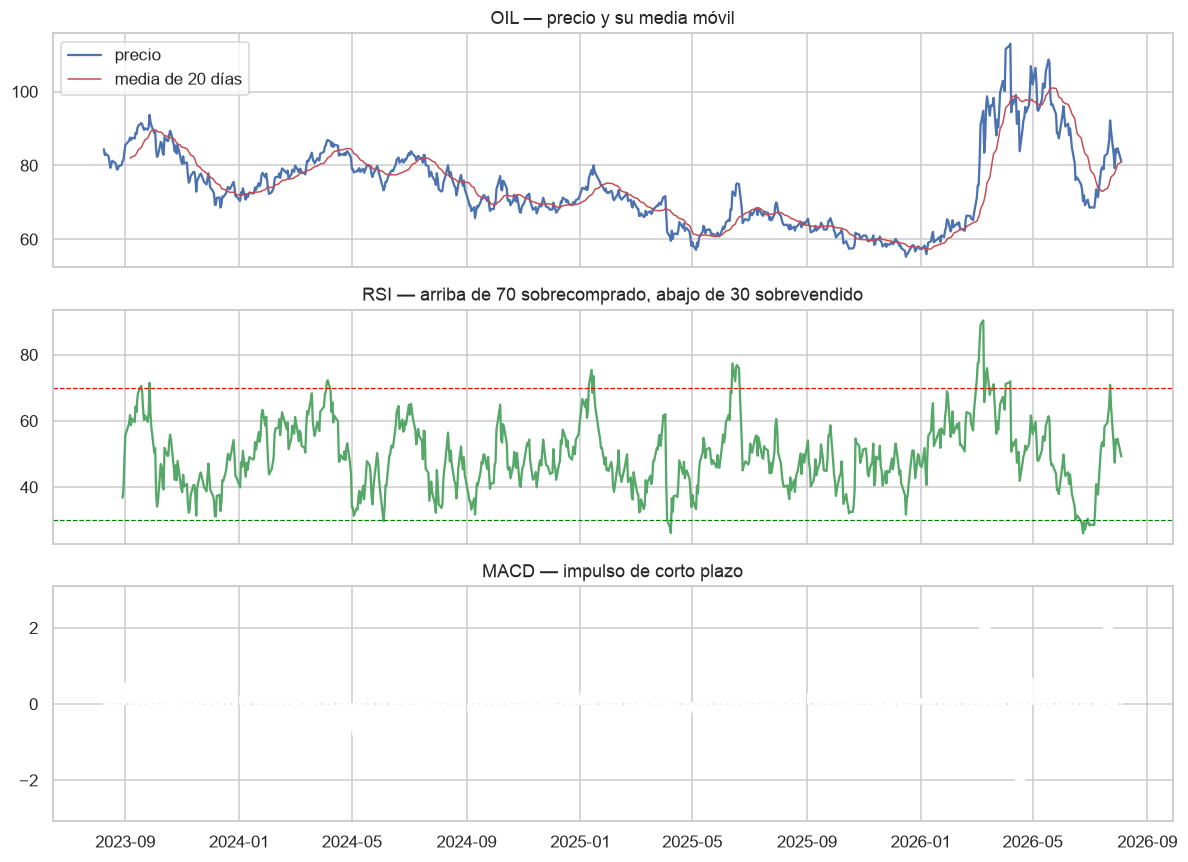

In [10]:
example = coverage["dias"].idxmax()
df = histories[example]
close = df["close"].to_numpy(dtype=np.float64)
rsi_vals = rsi_series(close)
sma20 = sma(close, 20)
macd = macd_histogram(close)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(df.index, close, label="precio", color=sns.color_palette()[0])
axes[0].plot(df.index, sma20, label="media de 20 días", color=sns.color_palette()[3], linewidth=1)
axes[0].set_title(f"{example} — precio y su media móvil")
axes[0].legend()

axes[1].plot(df.index, rsi_vals, color=sns.color_palette()[2])
axes[1].axhline(70, color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(30, color="green", linestyle="--", linewidth=0.8)
axes[1].set_title("RSI — arriba de 70 sobrecomprado, abajo de 30 sobrevendido")

axes[2].bar(df.index, macd, color=sns.color_palette()[4], width=1.0)
axes[2].set_title("MACD — impulso de corto plazo")

plt.tight_layout()
plt.show()

## 6. ¿Estos indicadores están diciendo cosas distintas, o se repiten?

In [11]:
feat_rows = []
for t, df in histories.items():
    X, y = build_features(df)
    feat_rows.append(
        pd.DataFrame(X, columns=FEATURE_NAMES).assign(target=y, ticker=t, date=df.index[1:])
    )
feat_panel = pd.concat(feat_rows, ignore_index=True).dropna(subset=["target"])
print(f"{len(feat_panel)} filas en total (un día de una acción = una fila)")

15702 filas en total (un día de una acción = una fila)


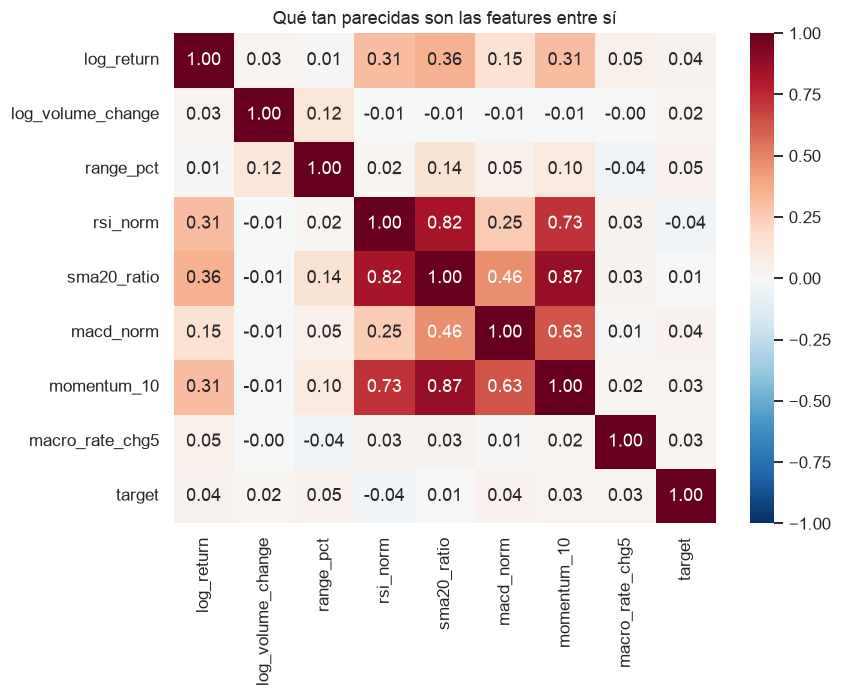

In [12]:
corr = feat_panel[FEATURE_NAMES + ["target"]].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Qué tan parecidas son las features entre sí")
plt.tight_layout()
plt.show()

`sma20_ratio`, `momentum_10` y `rsi_norm` correlacionan fuerte entre sí
(0.87 entre las primeras dos, arriba de 0.7 con el RSI) — las tres miden
más o menos lo mismo. `log_volume_change` y `macro_rate_chg5` no se
parecen a ninguna otra. Ninguna correlaciona fuerte con el `target` (máximo
0.05) — correlación solo mide relaciones en línea recta, así que eso no
quiere decir que no sirvan, solo que hay que mirarlas distinto (secciones
7 y 8).

## 7. ¿Alguno de estos indicadores realmente ayuda a predecir?

Agrupamos cada feature en 5 grupos —del valor más bajo al más alto— y
miramos cuánto rindió en promedio cada grupo.

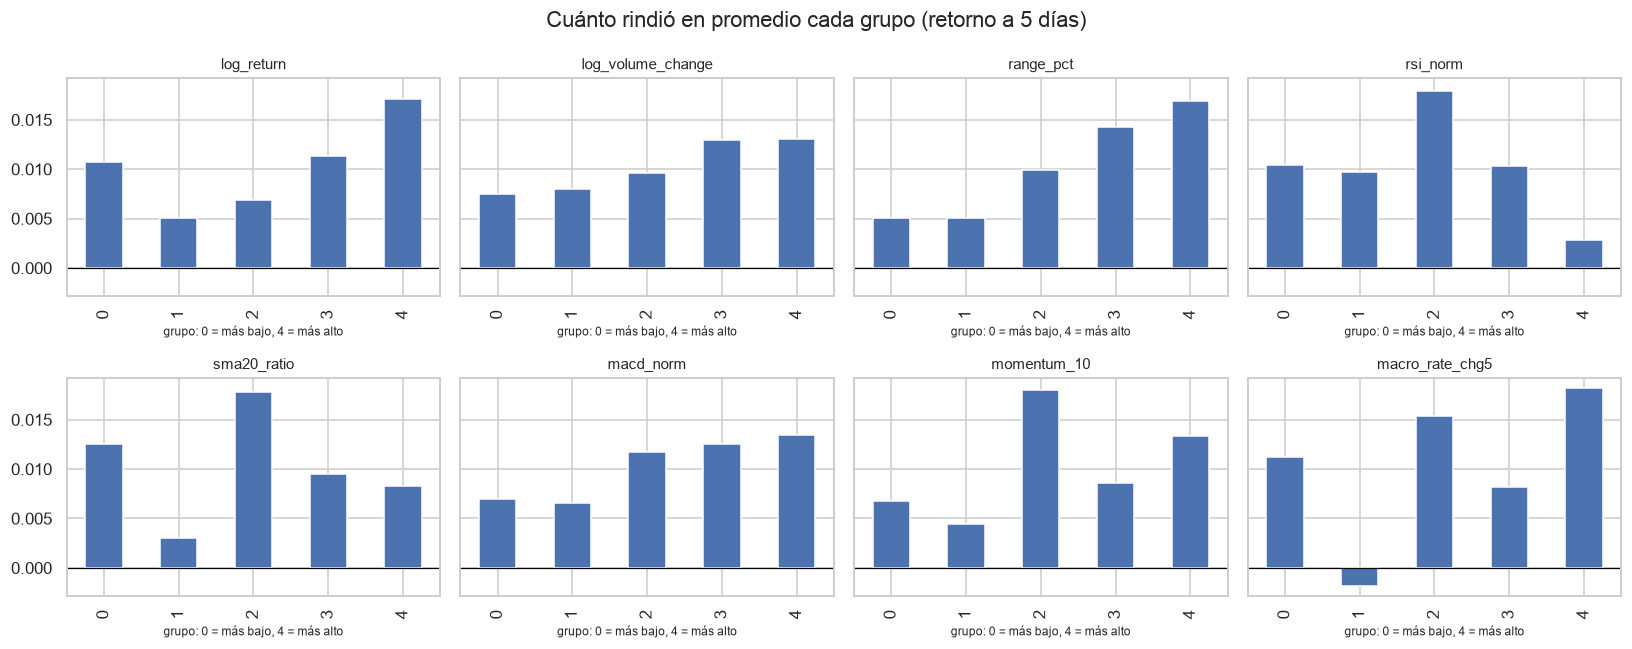

In [13]:
n_bins = 5
bucket_avg = {}
for feat in FEATURE_NAMES:
    bins = pd.qcut(feat_panel[feat], n_bins, labels=False, duplicates="drop")
    bucket_avg[feat] = feat_panel.groupby(bins)["target"].mean()

fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharey=True)
for ax, feat in zip(axes.flat, FEATURE_NAMES):
    bucket_avg[feat].plot.bar(ax=ax, color=sns.color_palette()[0])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("grupo: 0 = más bajo, 4 = más alto", fontsize=8)
fig.suptitle("Cuánto rindió en promedio cada grupo (retorno a 5 días)")
plt.tight_layout()
plt.show()

In [14]:
spread = pd.Series(
    {feat: bucket_avg[feat].max() - bucket_avg[feat].min() for feat in FEATURE_NAMES}
).sort_values(ascending=False)
print("diferencia entre el mejor grupo y el peor, por feature (más grande = más señal):")
spread

diferencia entre el mejor grupo y el peor, por feature (más grande = más señal):


macro_rate_chg5      0.020025
rsi_norm             0.015101
sma20_ratio          0.014771
momentum_10          0.013646
log_return           0.012053
range_pct            0.011872
macd_norm            0.006821
log_volume_change    0.005573
dtype: float64

## 8. ¿Todas las acciones se comportan igual?

Calculamos la correlación feature-target por separado para cada acción, y
vemos qué tan parecidas son entre sí esas 22 correlaciones.

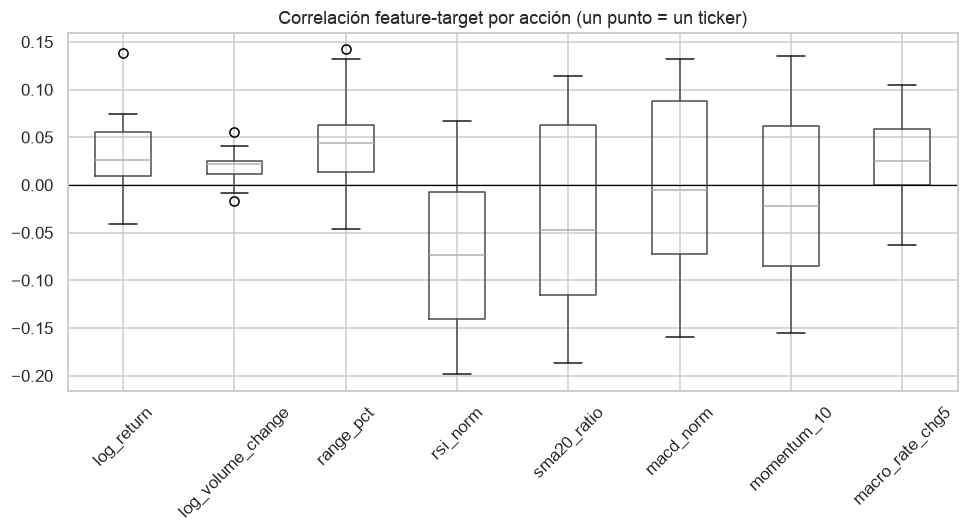

In [15]:
per_ticker_corr = feat_panel.groupby("ticker")[FEATURE_NAMES + ["target"]].apply(
    lambda g: g[FEATURE_NAMES].corrwith(g["target"])
)

fig, ax = plt.subplots(figsize=(9, 5))
per_ticker_corr.boxplot(ax=ax, rot=45)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Correlación feature-target por acción (un punto = un ticker)")
plt.tight_layout()
plt.show()

In [16]:
per_ticker_corr.describe().T[["mean", "std", "min", "max"]].sort_values("std", ascending=False)

,mean,std,min,max
sma20_ratio,-0.035811,0.100756,-0.186623,0.114522
macd_norm,0.005147,0.094446,-0.159004,0.132360
momentum_10,-0.010345,0.089507,-0.155166,0.135525
rsi_norm,-0.066442,0.081941,-0.198661,0.066930
range_pct,0.042726,0.050618,-0.045967,0.142177
macro_rate_chg5,0.029445,0.041486,-0.062715,0.105001
log_return,0.029144,0.040995,-0.040662,0.138165
log_volume_change,0.019364,0.015662,-0.017037,0.055531


`sma20_ratio`, `momentum_10` y `rsi_norm` — las mismas tres redundantes
entre sí de la sección 6 — son también las que más varían según la acción
(dispersión alta, llegan a ir de -0.19 a +0.14 según el ticker). No
parecen inútiles: parecen funcionar distinto en cada acción, y al
entrenar todo junto se puede estar promediando ese efecto hasta casi
anularlo. Esto lleva directo a la siguiente pregunta.

## 9. ¿Hay señal de momentum o de reversión en el retorno crudo, y a qué
plazo?

Hasta acá miramos indicadores calculados. Antes de inventar features
nuevas, conviene preguntarle a los datos algo más simple: si una acción
subió hoy, ¿tiende a seguir subiendo mañana (momentum) o a corregir
(reversión)? Y si hay algo, ¿a cuántos días se nota más fuerte? Esto es la
autocorrelación del retorno: cuánto se parece el retorno de hoy al de
hace *k* días, para cada *k* de 1 a 15.

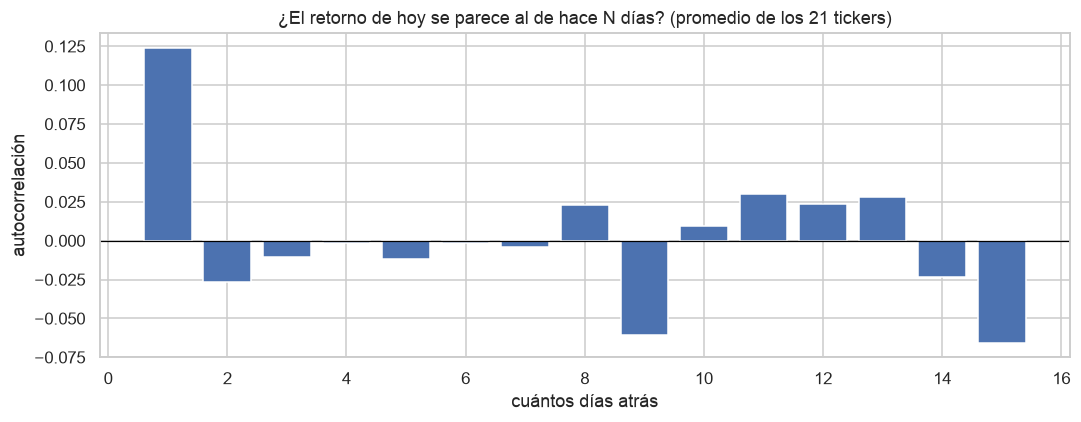

valor exacto por día:


1     0.123959
2    -0.026793
3    -0.010513
4    -0.001311
5    -0.011654
6    -0.001662
7    -0.003867
8     0.023038
9    -0.060701
10    0.009503
11    0.030134
12    0.023250
13    0.028109
14   -0.023428
15   -0.065592
dtype: float64

In [17]:
lags = 15
acf_by_ticker = []
for t, r in returns_by_ticker.items():
    if t in {"ECOG"}:
        continue
    vals = acf(r, nlags=lags, fft=True)
    acf_by_ticker.append(vals[1:])
acf_avg = np.mean(acf_by_ticker, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, lags + 1), acf_avg, color=sns.color_palette()[0])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("cuántos días atrás")
ax.set_ylabel("autocorrelación")
ax.set_title("¿El retorno de hoy se parece al de hace N días? (promedio de los 21 tickers)")
plt.tight_layout()
plt.show()

print("valor exacto por día:")
pd.Series(acf_avg, index=range(1, lags + 1))

Si algún lag sale claramente negativo, es reversión (sube hoy, bajaba
mañana); si sale positivo, es momentum (sigue en la misma dirección). El
horizonte que hoy usan los modelos para predecir es de 5 días
(`horizon=5` en `build_features`) — este gráfico dice si ese es un buen
número o si convendría otro (tarea "Probar otros hiperparámetros y
horizontes").

## 10. Una feature que no existe todavía: rendir mejor o peor que el
sector

Separamos las 21 acciones (sin ECOG, sin contar GOLD/OIL que son
comodities) en grupos por rubro, a ojo — corregir si alguno está mal
puesto:

- **Bancos**: GGAL, BMA, BBAR, SUPV, VALO, BYMA
- **Energía / servicios**: YPFD, PAMP, TGSU2, TGNO4, TRAN, CEPU, EDN, METR
- **Industria**: TXAR, ALUA, LOMA
- **Agro / holdings**: COME, CRES

La idea: en vez de mirar solo cuánto subió o bajó una acción por sí sola
(lo que ya miran `log_return`, `momentum_10`, etc.), calculamos cuánto
subió o bajó **comparado con el resto de su rubro ese mismo día**. Si
Galicia sube 2% pero todos los bancos suben 2%, no es información nueva.
Si Galicia sube 2% y el resto de los bancos bajan, eso sí puede ser una
señal distinta a la que ya tenemos.

In [18]:
sectors = {
    "bancos": ["GGAL", "BMA", "BBAR", "SUPV", "VALO", "BYMA"],
    "energia": ["YPFD", "PAMP", "TGSU2", "TGNO4", "TRAN", "CEPU", "EDN", "METR"],
    "industria": ["TXAR", "ALUA", "LOMA"],
    "agro_holding": ["COME", "CRES"],
}
ticker_to_sector = {t: s for s, ts in sectors.items() for t in ts if t in histories}
print(f"{len(ticker_to_sector)} de 22 tickers agrupados (afuera: ECOG + comodities GOLD/OIL)")

19 de 22 tickers agrupados (afuera: ECOG + comodities GOLD/OIL)


In [19]:
ret_rows = []
for t, sector in ticker_to_sector.items():
    df = histories[t]
    r = pd.Series(returns_by_ticker[t], index=df.index[1:])
    ret_rows.append(pd.DataFrame({"ticker": t, "sector": sector, "ret": r}))
ret_panel = pd.concat(ret_rows).rename_axis("date").reset_index()

sector_sum = ret_panel.groupby(["date", "sector"])["ret"].transform("sum")
sector_count = ret_panel.groupby(["date", "sector"])["ret"].transform("count")
# promedio del sector sin contar la propia acción (para no comparar una acción contra si misma)
ret_panel["sector_avg_sin_ella"] = (sector_sum - ret_panel["ret"]) / (sector_count - 1)
ret_panel["fuerza_relativa"] = ret_panel["ret"] - ret_panel["sector_avg_sin_ella"]

rel_panel = feat_panel.merge(
    ret_panel[["date", "ticker", "fuerza_relativa"]], on=["date", "ticker"], how="inner"
)
print(f"{len(rel_panel)} filas con fuerza relativa calculada")

13851 filas con fuerza relativa calculada


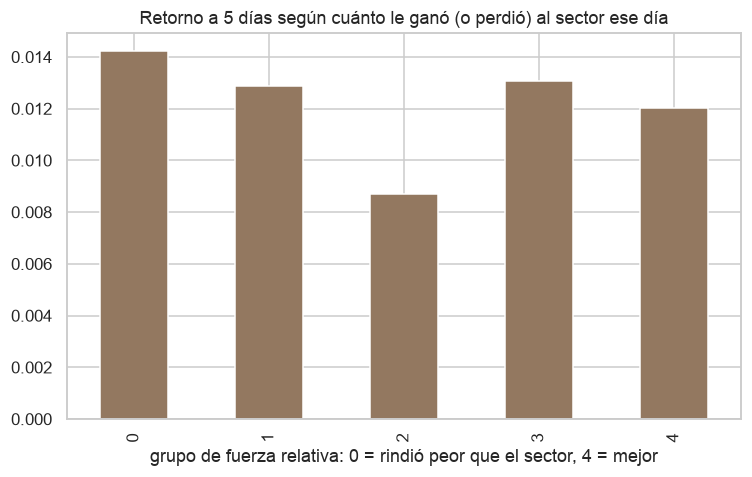

diferencia mejor-peor grupo: 0.0055  (comparar con la tabla de la sección 7)


In [20]:
bins = pd.qcut(rel_panel["fuerza_relativa"], n_bins, labels=False, duplicates="drop")
rel_bucket = rel_panel.groupby(bins)["target"].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
rel_bucket.plot.bar(ax=ax, color=sns.color_palette()[5])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("grupo de fuerza relativa: 0 = rindió peor que el sector, 4 = mejor")
ax.set_title("Retorno a 5 días según cuánto le ganó (o perdió) al sector ese día")
plt.tight_layout()
plt.show()

rel_spread = rel_bucket.max() - rel_bucket.min()
print(f"diferencia mejor-peor grupo: {rel_spread:.4f}  (comparar con la tabla de la sección 7)")

In [21]:
rel_per_ticker = rel_panel.groupby("ticker").apply(
    lambda g: g["fuerza_relativa"].corr(g["target"])
)
print("dispersión de esta correlación entre acciones (comparar con sección 8):")
print(f"  media={rel_per_ticker.mean():.3f} std={rel_per_ticker.std():.3f} "
      f"min={rel_per_ticker.min():.3f} max={rel_per_ticker.max():.3f}")

dispersión de esta correlación entre acciones (comparar con sección 8):
  media=-0.013 std=0.045 min=-0.090 max=0.066


/var/folders/1d/9jg8xmnn219f98tt4495rmhm0000gn/T/ipykernel_76579/1478287309.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rel_per_ticker = rel_panel.groupby("ticker").apply(


## 11. Otra que no existe todavía: volumen fuera de lo normal

`log_volume_change` mira el cambio de volumen día a día, pero no si ese
volumen es alto o bajo *para esa acción en particular* (una acción puede
operar habitualmente mucho más que otra). Calculamos un volumen "raro":
cuántos desvíos estándar se aleja el volumen de hoy del promedio de los
últimos 60 días, por acción.

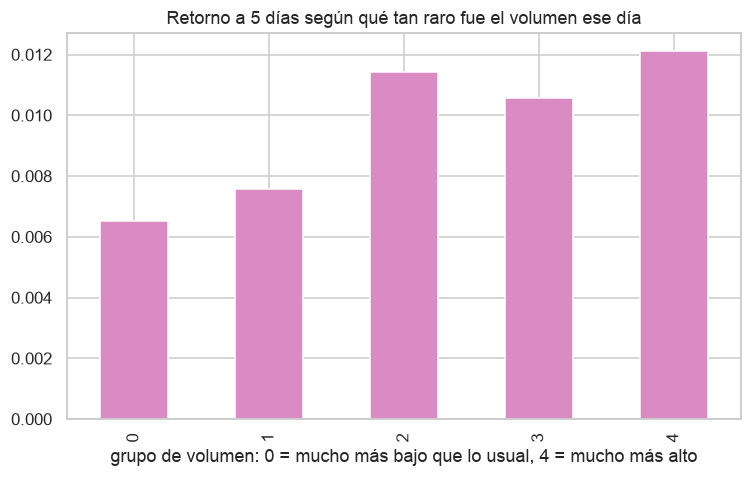

diferencia mejor-peor grupo: 0.0056


In [22]:
vol_rows = []
for t, df in histories.items():
    if t == "ECOG":
        continue
    vol = df["volume"].astype(float)
    roll_mean = vol.rolling(60, min_periods=20).mean()
    roll_std = vol.rolling(60, min_periods=20).std()
    z = (vol - roll_mean) / roll_std.replace(0, np.nan)
    vol_rows.append(pd.DataFrame({"ticker": t, "date": df.index, "vol_z": z.to_numpy()}))
vol_panel = pd.concat(vol_rows)

volz_panel = feat_panel.merge(vol_panel, on=["date", "ticker"], how="inner").dropna(subset=["vol_z"])
bins = pd.qcut(volz_panel["vol_z"], n_bins, labels=False, duplicates="drop")
volz_bucket = volz_panel.groupby(bins)["target"].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
volz_bucket.plot.bar(ax=ax, color=sns.color_palette()[6])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("grupo de volumen: 0 = mucho más bajo que lo usual, 4 = mucho más alto")
ax.set_title("Retorno a 5 días según qué tan raro fue el volumen ese día")
plt.tight_layout()
plt.show()

volz_spread = volz_bucket.max() - volz_bucket.min()
print(f"diferencia mejor-peor grupo: {volz_spread:.4f}")

## 12. ¿Combinar dos features da más señal que cada una por separado?

Probamos si un volumen raro *además de* un RSI extremo predice mejor que
cualquiera de las dos solas — 3 grupos de cada una, 9 combinaciones en
total.

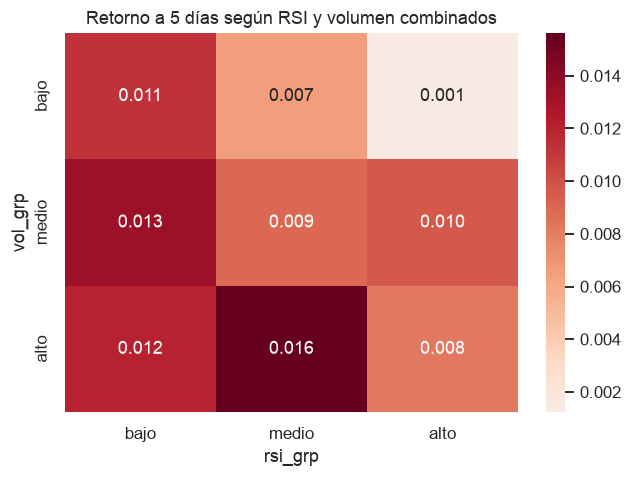

In [23]:
# volz_panel ya sale de mergear feat_panel (así que ya trae rsi_norm) con
# vol_panel -- no hace falta volver a mergear.
combo = volz_panel.copy()
combo["rsi_grp"] = pd.qcut(combo["rsi_norm"], 3, labels=["bajo", "medio", "alto"], duplicates="drop")
combo["vol_grp"] = pd.qcut(combo["vol_z"], 3, labels=["bajo", "medio", "alto"], duplicates="drop")
heat = combo.pivot_table(index="vol_grp", columns="rsi_grp", values="target", aggfunc="mean", observed=True)

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Retorno a 5 días según RSI y volumen combinados")
plt.tight_layout()
plt.show()

La celda "RSI medio + volumen alto" se despega del resto — pinta de que
juntar las dos cosas rinde más que cada una por separado. Antes de darlo
por bueno, construyámoslo como una feature de verdad y midámoslo con la
misma vara que usamos para las 8 actuales (sección 7), para poder
comparar cara a cara.

## 13. Construir candidatas de verdad, y compararlas contra las 8 actuales

Tres pruebas, cada una con su propio número de "diferencia entre el mejor
y el peor grupo" para comparar directo contra la tabla de la sección 7
(ahí el mejor de los 8 es `macro_rate_chg5`, con 0.0200).

### 13.a — Achicar el horizonte de predicción a 1 día

La sección 9 mostró que el retorno de hoy predice mucho más al de mañana
que al de cualquier otro día. Probemos directo: si en vez de predecir el
retorno acumulado a 5 días predecimos solo el de mañana, ¿el retorno de
hoy (`log_return`) se vuelve una feature bastante más fuerte?

log_return prediciendo a 1 día: diferencia mejor-peor grupo = 0.0116
  (contra 0.0121 que daba prediciendo a 5 días, y 0.0200 que es el mejor de los 8 a 5 días)


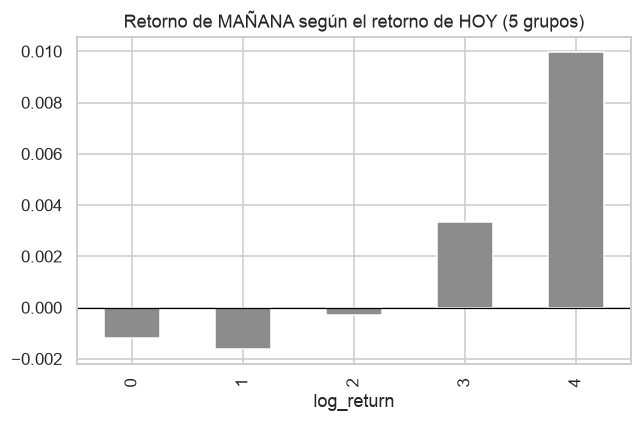

In [24]:
feat_rows_h1 = []
for t, df in histories.items():
    X, y = build_features(df, horizon=1)
    feat_rows_h1.append(pd.DataFrame(X, columns=FEATURE_NAMES).assign(target=y, ticker=t))
feat_panel_h1 = pd.concat(feat_rows_h1, ignore_index=True).dropna(subset=["target"])

bins = pd.qcut(feat_panel_h1["log_return"], n_bins, labels=False, duplicates="drop")
bucket_h1 = feat_panel_h1.groupby(bins)["target"].mean()
spread_h1 = bucket_h1.max() - bucket_h1.min()
print(f"log_return prediciendo a 1 día: diferencia mejor-peor grupo = {spread_h1:.4f}")
print("  (contra 0.0121 que daba prediciendo a 5 días, y 0.0200 que es el mejor de los 8 a 5 días)")

fig, ax = plt.subplots(figsize=(6, 4))
bucket_h1.plot.bar(ax=ax, color=sns.color_palette()[7])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Retorno de MAÑANA según el retorno de HOY (5 grupos)")
plt.tight_layout()
plt.show()

### 13.b — La combinación RSI medio + volumen alto, como feature propia

En vez de mirar el mapa completo, armamos una sola columna: 1 si ese día
el RSI está en el tercio del medio y el volumen en el tercio más alto, 0
si no.

In [25]:
combo["rsi_vol_combo"] = ((combo["rsi_grp"] == "medio") & (combo["vol_grp"] == "alto")).astype(int)
media_con = combo.loc[combo["rsi_vol_combo"] == 1, "target"].mean()
media_sin = combo.loc[combo["rsi_vol_combo"] == 0, "target"].mean()
print(f"con la combinación: {media_con:.4f}   sin ella: {media_sin:.4f}")
print(f"diferencia: {media_con - media_sin:.4f}  "
      f"({(combo['rsi_vol_combo']==1).mean():.1%} de los días la tienen)")

con la combinación: 0.0156   sin ella: 0.0091
diferencia: 0.0066  (8.9% de los días la tienen)


### 13.c — Qué tan lejos está del máximo reciente

Otra que no habíamos probado: distancia del precio de hoy al máximo de los
últimos 60 días (0 = está en el máximo, negativo = por debajo). La idea es
capturar si está rompiendo un techo o recién saliendo de un piso, algo que
el RSI y el SMA20 no ven igual porque miran ventanas más cortas (14 y 20
días, no 60).

distancia al máximo de 60 días: diferencia mejor-peor grupo = 0.0236


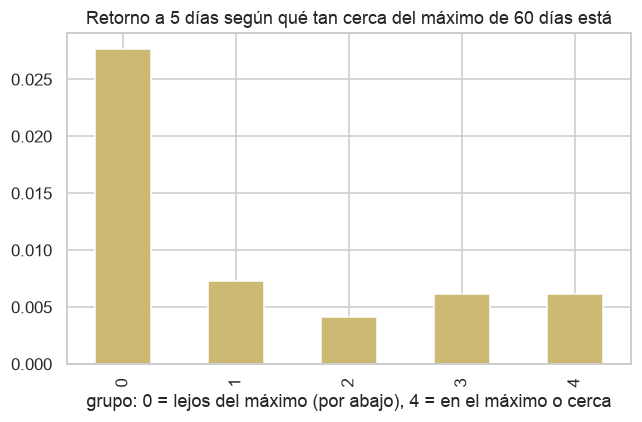

In [26]:
dist_rows = []
for t, df in histories.items():
    if t == "ECOG":
        continue
    close = df["close"]
    roll_max = close.rolling(60, min_periods=30).max()
    dist = close / roll_max - 1.0
    dist_rows.append(pd.DataFrame({"ticker": t, "date": df.index, "dist_max60": dist.to_numpy()}))
dist_panel = pd.concat(dist_rows)

distmax_panel = feat_panel.merge(dist_panel, on=["date", "ticker"], how="inner").dropna(subset=["dist_max60"])
bins = pd.qcut(distmax_panel["dist_max60"], n_bins, labels=False, duplicates="drop")
distmax_bucket = distmax_panel.groupby(bins)["target"].mean()
distmax_spread = distmax_bucket.max() - distmax_bucket.min()
print(f"distancia al máximo de 60 días: diferencia mejor-peor grupo = {distmax_spread:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
distmax_bucket.plot.bar(ax=ax, color=sns.color_palette()[8])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("grupo: 0 = lejos del máximo (por abajo), 4 = en el máximo o cerca")
ax.set_title("Retorno a 5 días según qué tan cerca del máximo de 60 días está")
plt.tight_layout()
plt.show()

## Conclusiones para los modelos

### La feature nueva que más prometió: distancia al máximo de 60 días

1. **Cuando una acción cayó fuerte respecto a su máximo de los últimos 60
   días, en los próximos 5 días tiende a recuperar terreno.** Mirando el
   gráfico de la 13.c: el grupo más alejado del máximo (cayó fuerte) rinde
   0.0275 en promedio, contra 0.004-0.007 de los otros cuatro grupos —
   la diferencia total (0.0236) le gana a las 8 features actuales, incluso
   a la mejor de ellas (la tasa macro, con 0.0200). Importante: no es un
   efecto parejo a lo largo de todo el rango, está concentrado casi todo
   en ese grupo de caída fuerte — es más "después de un batacazo grande
   suele haber rebote" que "cuanto más lejos del máximo, mejor".
   **Recomendación concreta: agregar `dist_max60` (precio actual contra el
   máximo de los últimos 60 días) como noveno feature en
   `src/lstm.py::FEATURE_NAMES`, reentrenar los 3 modelos y correr
   `make backtest` para confirmar que el efecto se sostiene fuera de esta
   muestra.**

### Una pista real, aunque más chica

2. **Volumen alto + RSI en zona media (no extrema) predice mejor que
   cualquiera de las dos por separado.** Como feature binaria (1 si pasan
   las dos cosas juntas, sección 13.b): los días que la tienen rinden
   0.0156 en promedio contra 0.0091 los que no — una diferencia real
   (0.0066), aunque se da en pocos días (9% del total) y por debajo de la
   de `dist_max60`. Vale la pena sumarla como una segunda feature nueva,
   con menos prioridad que la del punto 1.

### Una corrección a algo que habíamos supuesto mal

3. **Achicar el horizonte de predicción a 1 día NO ayuda**, al menos no
   así de simple. La sección 9 había mostrado que el retorno de hoy se
   parece más al de mañana que al de cualquier otro día (autocorrelación
   0.124, la más alta de 15 lags) y de ahí habíamos sacado que convenía
   probar un horizonte más corto. Lo probamos en la 13.a: prediciendo a 1
   día, `log_return` da un spread de 0.0116 — prácticamente **igual** al
   0.0121 que ya daba prediciendo a 5 días. La correlación más alta a 1
   día no se traduce en más señal aprovechable con este método. No
   descartamos la idea de probar otros horizontes (sigue siendo parte de
   la tarea "Probar otros hiperparámetros y horizontes"), pero no es por
   esta razón puntual — hay que probarlo por las suyas, no porque el ACF
   lo garantice.

### Lo que probamos y no dio bien (para no repetirlo)

4. **La fuerza relativa al sector (sección 10) predijo poco por sí sola**
   (spread 0.0055, de los más bajos que medimos) — aunque es más estable
   entre acciones que `sma20_ratio`/`momentum_10`/`rsi_norm`. No la
   tiramos del todo: antes de descartarla, probar con otra ventana de
   comparación o agrupamiento sectorial.
5. **El volumen inusual solo (sección 11) tampoco predice mucho** (spread
   0.0056) — pero combinado con el RSI sí aparece algo (punto 2): como
   feature aislada no suma, como parte de una interacción, sí.

### Lo que ya sabíamos, con más evidencia

6. **Revisar el dato de ECOG** antes de seguir usándolo — cae ~90% en un
   día y tiene mucha menos historia que el resto (sección 3).
7. **`sma20_ratio`, `momentum_10` y `rsi_norm` se repiten entre sí y
   además varían mucho por acción** (secciones 6 y 8) — evidencia de que
   un modelo por ticker o por grupo de tickers puede rendir mejor que el
   pooled actual para estas tres en particular.
8. **`log_volume_change` sigue siendo la más floja de las 8 sola**
   (sección 7) — probar antes la versión de interacción (punto 2) que
   sacarla directamente.